<h3 align="center" style="margin:0px">
    <img width="200" src="../_assets/images/logo_purple.png" alt="Kinetica Logo"/>
</h3>
<h5 align="center" style="margin:0px">
    <a href="https://www.kinetica.com/">Website</a>
    <span> | </span>
    <a href="https://docs.kinetica.com/7.2/">Docs</a>
    <span> | </span>
    <a href="https://docs.kinetica.com/7.2/api/">API Docs</a>
    <span> | </span>
    <a href="https://join.slack.com/t/kinetica-community/shared_invite/zt-1bt9x3mvr-uMKrXlSDXfy3oU~sKi84qg">Community Slack</a>   
</h5>

# WMS Visualization Demo

Visualize WMS with an interactive widget — Kinetica handles all rendering server-side via its WMS endpoint, and the notebook just shows the resulting tiles in an `ipyleaflet` map with zoom/pan.

## Cells

1. **Install** `gpudb`, `ipywidgets`, `ipyleaflet`.
2. **Connect** to Kinetica using `$KINETICA_URL`, `$KINETICA_USER`, `$KINETICA_PASSWD`.
3. **Load tracks** — read `adsb_tracks.csv` into a DataFrame and convert the epoch-ms `TIMESTAMP` column to `datetime64[ns]`. A commented-out `GPUdbTable.from_df` call pushes the rows into Kinetica as the `adsb_tracks` source table.
4. **Points view** — `CREATE OR REPLACE TEMP MATERIALIZED VIEW` of the tracks table without `TRACKID`, so Kinetica renders it as points (not tracks).
5. **Shapes table** — load `states_shapes.csv` into a Kinetica table with a `kiGeometry GEOMETRY` column for shape rendering.
6. **WMS proxy + `wms_fetch()`** — a tiny stdlib `ThreadingHTTPServer` in a daemon thread forwards browser tile requests through `KDBC.wms()`, so credentials never appear in URLs the browser sees. Each request is logged to a shared `WMS_LOG` widget; XML `ServiceException`s from Kinetica are parsed and routed to a per-map status banner via the `_WMS_STATUS` registry. `wms_fetch(params)` is a direct helper that returns the raw WMS bytes and raises `RuntimeError` if Kinetica returns an XML error instead of a PNG.
7. **Direct PNG test** — uses `wms_fetch()` to confirm the endpoint, auth, and params work in isolation, bypassing ipyleaflet.
8. **`show_wms(table, params, *, basemap=...)`** — renders any table/view as a `WMSLayer` on a Leaflet map and returns a `VBox(status_banner, map)`. The banner above each map shows the latest `ServiceException` for *that* map (cleared on the next successful tile), keyed by a per-call `_mapid` UUID that also doubles as a cache-buster so Leaflet always re-requests tiles. `params` carries the render-mode keys (`STYLES`, `DOTRACKS`, `TRACK_*`/`POINT_*`/`SHAPE_*` styling) so the same helper handles *tracks*, *points*, and *shapes* modes. `OSM_DARK` is a custom Stadia template (supports an API key); `OSM_LIGHT` and `CARTO_DARK` come from `ipyleaflet.basemaps`.
9. **Examples** — render the points view, the tracks table, and the states shapes table with their respective param dicts.

## WMS endpoint

Per [docs.kinetica.com/7.2/api/rest/wms_rest](https://docs.kinetica.com/7.2/api/rest/wms_rest/), the GET `/wms` endpoint takes `LAYERS`, `BBOX`, `WIDTH`/`HEIGHT`, `SRS`, plus `STYLES=raster`/`cb_raster`/`heatmap` and the `TRACK_*`/`POINT_*`/`SHAPE_*` styling family. ipyleaflet supplies the BBOX/WIDTH/HEIGHT/SRS envelope per tile; the helper appends the rest.

## Notes

- **SRS is intentionally not hardcoded** — Leaflet derives it from the map's CRS (EPSG:3857) and produces a matching BBOX. Forcing `EPSG:4326` in the URL fights Leaflet's BBOX and renders nothing.
- **Stadia (OSM_DARK) needs an API key** off-localhost. Set `STADIA_API_KEY` env var, or use `CARTO_DARK`/`OSM_LIGHT`.

In [1]:
# install Kinetica package
%pip install -U -q 'gpudb[dataframe]>=7.2' 

# install packages needed for Jupyter widgets and the map viewer
%pip install -U -q ipykernel ipywidgets ipyleaflet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from gpudb import GPUdb
import os
from pathlib import Path
import pandas as pd
from gpudb import GPUdbTable

# these are expected by GPUdb.get_connection()
HOST = os.environ['KINETICA_URL']
USER = os.environ['KINETICA_USER']
PASSWORD = os.environ['KINETICA_PASSWD']

# convenience function to create a KDBC connection
KDBC: GPUdb = GPUdb.get_connection()
DATA_DIR = Path("./data")

2026-05-19 23:10:31.009 INFO     [GPUdb] Connected to Kinetica! (host=http://172.31.33.30:9191 api=7.2.3.8 server=7.2.3.13)


In [3]:
# Load tracks from CSV into a DataFrame and push to Kinetica. 
#
# For Kinetica WMS to render this as a "tracks" layer, the table needs:
#   TRACKID    (string)                — track identifier
#   TIMESTAMP  (long ms, or DATETIME)  — ordering within a track
#   x, y       (float)                 — point coordinates

TRACKS_TABLE = 'user_cjuliano.adsb_tracks'

load_df = pd.read_csv(DATA_DIR / "adsb_tracks.csv")

# CSV stores TIMESTAMP as epoch milliseconds. `pd.to_datetime(..., unit='ms')`
# returns datetime64[ms] in pandas 2.x; cast to datetime64[ns] so downstream
# code/libs that assume the historical ns resolution don't choke.
load_df['TIMESTAMP'] = pd.to_datetime(load_df['TIMESTAMP'], unit='ms').astype('datetime64[ns]')

display(load_df.head())
gpudb_table = GPUdbTable.from_df(load_df, db=KDBC, 
                                table_name=TRACKS_TABLE, 
                                clear_table=True,
                                load_data=True)

print(f'{gpudb_table.count} records in {TRACKS_TABLE}')

,TRACKID,TIMESTAMP,x,y,alt,hexid,reg,squawk,vertRate,ident,orig,dest
0,UAL1705-1697380370-fa-1584p,2023-10-18 13:55:11,-74.16864,40.69217,100,AC4107,N889UA,7164,3008,UAL1705,KEWR,KSTL
1,UAL1705-1697380370-fa-1584p,2023-10-18 13:55:27,-74.16252,40.70081,675,AC4107,N889UA,7164,1536,UAL1705,KEWR,KSTL
2,UAL1705-1697380370-fa-1584p,2023-10-18 13:55:43,-74.15316,40.70863,1075,AC4107,N889UA,7164,1152,UAL1705,KEWR,KSTL
3,UAL1705-1697380370-fa-1584p,2023-10-18 13:55:59,-74.13989,40.71808,1475,AC4107,N889UA,7164,1664,UAL1705,KEWR,KSTL
4,UAL1705-1697380370-fa-1584p,2023-10-18 13:56:15,-74.12550,40.72823,2000,AC4107,N889UA,7164,2816,UAL1705,KEWR,KSTL


853 records in user_cjuliano.adsb_tracks


In [12]:
# Create a materialized view of the tracks table but without TRACKID 
# so Kinetica will recognize it as points to render in the WMS viewer.
# 
# Note: If Kinetica identifies the table as having tracks then the WMS points 
# attributes will be ignored.
POINTS_TABLE = 'user_cjuliano.adsb_points_v'

sql = f"""
SELECT TIMESTAMP, x, y, alt, hexid, reg, squawk, vertRate, ident, orig, dest
FROM {TRACKS_TABLE}
"""
rec_count = KDBC.execute(f'CREATE OR REPLACE TEMP MATERIALIZED VIEW {POINTS_TABLE} AS {sql}')
print(f'{rec_count} records in {POINTS_TABLE}')

853 records in user_cjuliano.adsb_points_v


In [ ]:
# Load US states shapes from CSV into a DataFrame and push to Kinetica. 
SHAPES_TABLE = 'user_cjuliano.states_shapes'

# Load the states shapes data from a CSV file into a dataframe
load_df = pd.read_csv(DATA_DIR / "states_shapes.csv")

# Create a table with a GEOMETRY column to hold the shapes data.
sql=f"""
CREATE or replace TABLE {SHAPES_TABLE}
(
    "STATE_ABBR" VARCHAR (32) NOT NULL,
    "NAME" VARCHAR (128) NOT NULL,
    "kiGeometry" GEOMETRY
)
"""
KDBC.execute(sql)

# Insert the shapes data into the table.
table = GPUdbTable(db=KDBC, name=SHAPES_TABLE)
display(table.type_as_df())

table.insert_records(load_df.to_dict(orient='records'))
print(f'{table.count} records in {SHAPES_TABLE}')

,name,type,properties
0,STATE_ABBR,string,"[char32, data]"
1,NAME,string,"[char128, data]"
2,kiGeometry,string,"[data, nullable, wkt]"


3 records in user_cjuliano.states_shapes


In [6]:
import html
import threading
import time
import urllib.parse
import xml.etree.ElementTree as ET
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from IPython.display import display
from ipywidgets import Output

WMS_LOG = Output(layout={'border': '1px solid #ccc', 'max_height': '240px',
                        'overflow': 'auto', 'font_family': 'monospace'})

if '_WMS_STATUS' not in globals():
    _WMS_STATUS: dict = {}

def _wms_log(msg: str) -> None:
    WMS_LOG.append_stdout(f'{time.strftime("%H:%M:%S")} {msg}\n')

def _wms_status(map_id: str, msg: str) -> None:
    """Set or clear the status banner for a specific map.

    `msg=''` clears. A non-empty `msg` shows a red banner above the map.
    Called from the proxy's request thread, so we just assign to the
    widget's `value` trait (thread-safe; ipywidgets syncs to the frontend).
    """
    w = _WMS_STATUS.get(map_id)
    if w is None:
        return
    w.value = (
        f'<div style="background:#fee;border:1px solid #c33;padding:8px;'
        f'color:#900;font-family:monospace;">⚠ {html.escape(msg)}</div>'
        if msg else ''
    )

def _wms_call(qs: str) -> bytes:
    """Forward a WMS query string to Kinetica and return raw response bytes.

    Kinetica signals errors by returning a `ServiceExceptionReport` XML
    document instead of an image. When that happens this parses out the
    `<ServiceException>` text and raises `RuntimeError` with just that
    message, so callers get a clean error rather than a raw XML blob.
    """
    data = bytes(KDBC.wms(qs)['data'])
    if data[:5] == b'<?xml':
        try:
            msg = (ET.fromstring(data).findtext('.//ServiceException') or '').strip()
        except ET.ParseError:
            msg = data.decode('utf-8', 'replace').strip()
        raise RuntimeError(msg or 'WMS error (empty exception)')
    return data

def wms_fetch(params: dict[str, str]) -> bytes:
    """Fetch a WMS response from Kinetica via the existing KDBC connection.

    Forwards `params` (a dict of WMS query keys such as LAYERS, BBOX,
    WIDTH/HEIGHT, STYLES, etc.) to the `/wms` endpoint and returns the raw
    response bytes — typically a PNG image. Raises `RuntimeError` with the
    parsed `ServiceException` text if Kinetica returns an XML error.
    Endpoint shape per https://docs.kinetica.com/7.2/api/rest/wms_rest/.
    """
    return _wms_call(urllib.parse.urlencode(params))

class _WMSProxy(BaseHTTPRequestHandler):
    """Local WMS proxy: serves PNG tiles to ipyleaflet by forwarding query
    params to Kinetica's /wms endpoint via the existing KDBC connection.
    Keeps credentials out of URLs the browser sees. Each request is logged
    to WMS_LOG so you can see what Kinetica is being asked and what it
    returns. Endpoint shape per
    https://docs.kinetica.com/7.2/api/rest/wms_rest/.
    """

    def do_GET(self) -> None:
        qs = urllib.parse.urlparse(self.path).query
        params = dict(urllib.parse.parse_qsl(qs, keep_blank_values=True))
        layers = params.get('LAYERS', '?')
        bbox = params.get('BBOX', '')
        map_id = params.get('_mapid', '')

        try:
            data = _wms_call(qs)
        except RuntimeError as e:
            _wms_log(f'ERROR layers={layers} bbox={bbox}\n  {e}')
            _wms_status(map_id, str(e))
            self.send_error(502, f'WMS exception: {e}')
            return
        except Exception as e:
            _wms_log(f'EXC   layers={layers} bbox={bbox}\n  {type(e).__name__}: {e}')
            _wms_status(map_id, f'{type(e).__name__}: {e}')
            self.send_error(502, str(e))
            return
        
        _wms_log(f'OK    layers={layers} bbox={bbox} -> {len(data)}B')
        _wms_status(map_id, '')  # clear any prior error banner for this map
        
        self.send_response(200)
        self.send_header('Content-Type', 'image/png')
        self.send_header('Content-Length', str(len(data)))
        self.end_headers()
        self.wfile.write(data)

    def log_message(self, *args: object) -> None:
        pass

if 'WMS_PROXY_URL' not in globals():
    _srv = ThreadingHTTPServer(('127.0.0.1', 0), _WMSProxy)
    threading.Thread(target=_srv.serve_forever, daemon=True).start()
    WMS_PROXY_URL = f'http://127.0.0.1:{_srv.server_port}/wms'

print(WMS_PROXY_URL)
display(WMS_LOG)
_wms_log('WMS proxy ready')

http://127.0.0.1:53681/wms


Output(layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_right='1px solid #cc…

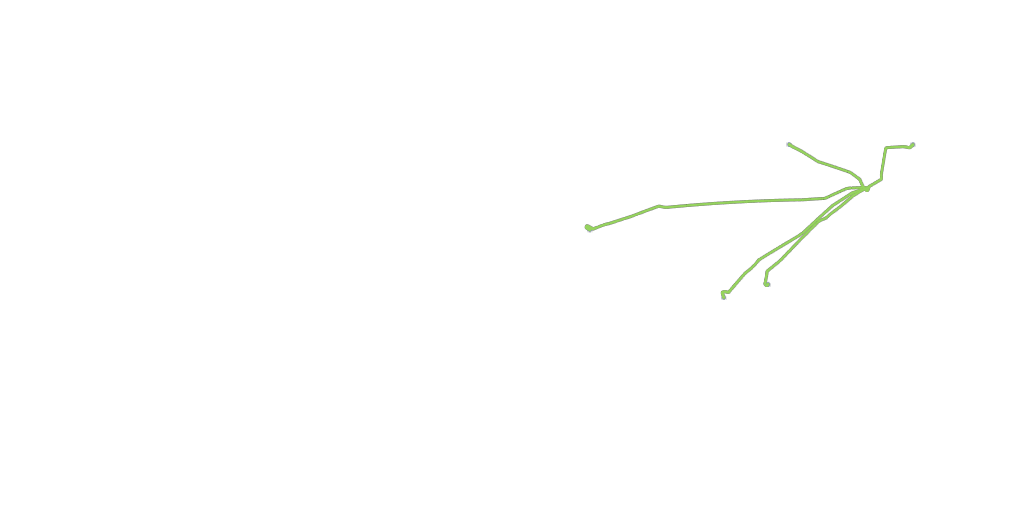

In [7]:
# Direct WMS fetch — bypasses ipyleaflet to confirm the endpoint, auth,
# and params are working. If this returns a PNG, the pipeline is fine.
# If it shows an XML error, the message points at the real cause.
from IPython.display import Image

tracks_params = {
    'X_ATTR': 'x', 'Y_ATTR': 'y',
    'STYLES': 'raster',
    'DOTRACKS': 'TRUE',
    'TRACK_ID_ATTR': 'TRACKID', 'TRACK_ORDER_ATTR': 'TIMESTAMP',
    'TRACKLINECOLORS': '4F7A28', 'TRACKLINEWIDTHS': '2',
    'TRACKHEADCOLORS': '3A88FE', 'TRACKHEADSIZES': '3',
    'TRACKMARKERCOLORS': '96D35F', 'TRACKMARKERSIZES': '2',
}

test_params = {
    **tracks_params,
    'REQUEST': 'GetMap',
    'SERVICE': 'WMS',
    'VERSION': '1.1.1',
    'FORMAT': 'image/png',
    'TRANSPARENT': 'TRUE',
    'SRS': 'EPSG:4326',
    'BBOX': '-125,25,-65,50',  # CONUS
    'WIDTH': '1024', 'HEIGHT': '512',
    'LAYERS': TRACKS_TABLE,
}
Image(wms_fetch(test_params))

In [8]:
import uuid
from urllib.parse import urlencode
from ipyleaflet import Map, WMSLayer, basemaps
from ipywidgets import HTML, Layout, VBox
from xyzservices import TileProvider

# Stadia Maps requires an API key off-localhost (e.g. VSCode webviews → 401).
# Free key at stadiamaps.com; leave unset for local Jupyter.
STADIA_API_KEY = os.getenv('STADIA_API_KEY')

# Wrap with TileProvider (not a plain dict) so ipyleaflet substitutes
# {variant}/{ext}/{s} placeholders before requesting tiles.
_stadia = basemaps.Stadia.AlidadeSmoothDark
OSM_DARK = TileProvider({**_stadia,
                         'url': _stadia['url'] + (f'?api_key={STADIA_API_KEY}' if STADIA_API_KEY else '')})

OSM_LIGHT = basemaps.OpenStreetMap.Mapnik
CARTO_DARK = basemaps.CartoDB.DarkMatter


def show_wms(table: str, params: dict[str, str], *,
             basemap: TileProvider = OSM_LIGHT,
             center: tuple[float, float] = (36.6, -87.7),
             zoom: int = 5, height: str = '600px') -> VBox:
    """Render a Kinetica WMS layer for `table` (any table or view).

    Returns a `VBox(status_banner, map)`. The banner is a per-call HTML
    widget registered in `_WMS_STATUS` under a unique `map_id`; if a tile
    request fails, the proxy sets that widget's value so the error appears
    above this specific map. A successful tile clears the banner.

    `params` carries all render-mode-specific WMS keys (X_ATTR, Y_ATTR,
    STYLES, DOTRACKS, TRACK_*/POINT_*, etc.). Tracks example:
    `{'X_ATTR': 'x', 'Y_ATTR': 'y', 'STYLES': 'raster', 'DOTRACKS': 'TRUE',
    'TRACK_ID_ATTR': 'TRACKID', 'TRACK_ORDER_ATTR': 'TIMESTAMP',
    'TRACKLINECOLORS': '4F7A28', ...}`. Points example:
    `{'X_ATTR': 'Longitude', 'Y_ATTR': 'Latitude', 'STYLES': 'raster',
    'DOTRACKS': 'FALSE', 'POINTCOLORS': '96D35F', 'POINTSIZES': '3'}`.

    `basemap` accepts any of OSM_DARK, OSM_LIGHT, CARTO_DARK (or a custom dict).

    SRS is intentionally not set: ipyleaflet's WMSLayer derives it from the
    map's CRS (EPSG:3857 by default) and supplies BBOX in matching units.
    Hardcoding SRS here would fight Leaflet's BBOX and render nothing.
    """
    _wms_log(f'rendering {table}')
    
    # Unique per-call id: routes proxy errors back to *this* map's status
    # banner, and doubles as a cache-buster (Leaflet sees a fresh URL each
    # call, so a previously failed tile gets re-requested).
    map_id = uuid.uuid4().hex
    status = HTML(value='')
    _WMS_STATUS[map_id] = status
    url = f'{WMS_PROXY_URL}?{urlencode({**params, "_mapid": map_id})}'
    layer = WMSLayer(url=url, layers=table, format='image/png',
                     transparent=True, uppercase=True)
    m = Map(basemap=basemap, center=center, zoom=zoom, scroll_wheel_zoom=True,
            layout=Layout(height=height))
    m.add_layer(layer)
    return VBox([status, m])

In [9]:
# Render the points view with WMS
points_params = {
    'X_ATTR': 'x', 'Y_ATTR': 'y',
    'STYLES': 'raster',
    'POINTCOLORS': 'F00000', 'POINTSIZES': '2',
}
show_wms(POINTS_TABLE, points_params, height='400px')

In [10]:
# Render the tracks view with WMS
tracks_params = {
    'X_ATTR': 'x', 'Y_ATTR': 'y',
    'STYLES': 'raster',
    'DOTRACKS': 'TRUE',
    'TRACK_ID_ATTR': 'TRACKID', 'TRACK_ORDER_ATTR': 'TIMESTAMP',
    'TRACKLINECOLORS': 'A0F00000', 'TRACKLINEWIDTHS': '1',
    'TRACKHEADCOLORS': '0000FF', 'TRACKHEADSIZES': '6',
    'TRACKMARKERCOLORS': 'F00000', 'TRACKMARKERSIZES': '2',
}
show_wms(TRACKS_TABLE, tracks_params, height='400px')

In [11]:
shapes_params = {
    'STYLES': 'raster',
    'GEO_ATTR': 'kiGeometry',
    'DOSHAPES': 'TRUE',
    'SHAPEFILLCOLORS': '50F00000',
    'SHAPELINECOLORS': 'F00000',
    'SHAPELINEWIDTHS': '2',
}
show_wms(SHAPES_TABLE, shapes_params, height='400px')